# Analise Exploratoria - Publico-Alvo Priceless Bank (40 a 60 anos)

> Recorte da base no **publico-alvo redefinido: clientes de 40 a 60 anos**.
> Objetivo: entender quem e, quanto pesa, como consome e onde estao as alavancas desse segmento.
> Data de referencia ("hoje"): `2025-12-31`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

MC_RED = '#EB001B'      # Vermelho Mastercard
MC_ORANGE = '#F79E1B'   # Laranja Mastercard
MC_GRAY = '#9E9E9E'
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

DATA = Path('data') if Path('data').exists() else Path('../data')
GRAF = Path('graficos'); GRAF.mkdir(exist_ok=True)
HOJE = pd.Timestamp('2025-12-31')

clientes      = pd.read_csv(DATA / 'Base_clientes.csv')
cartoes       = pd.read_csv(DATA / 'Base_cartoes.csv')
transacoes    = pd.read_csv(DATA / 'Base_transacoes.csv')
pix           = pd.read_csv(DATA / 'Base_pix.csv')
investimentos = pd.read_csv(DATA / 'Base_investimentos.csv')

# Idade e recorte do publico-alvo (40 a 60 anos)
clientes['Data_Nascimento'] = pd.to_datetime(clientes['Data_Nascimento'], dayfirst=True, errors='coerce')
clientes['Idade'] = ((HOJE - clientes['Data_Nascimento']).dt.days / 365.25)
clientes['Publico_Alvo'] = clientes['Idade'].between(40, 60, inclusive='both')

alvo  = clientes[clientes['Publico_Alvo']].copy()
resto = clientes[~clientes['Publico_Alvo']].copy()

transacoes['Data'] = pd.to_datetime(transacoes['Data'], errors='coerce')
tx_2025  = transacoes[transacoes['Data'].dt.year == 2025]
alvo_ids = set(alvo['Cliente_ID'])
inv_ids  = set(investimentos['Cliente_ID'].unique())

# KPIs do segmento
n_alvo, n_total = len(alvo), len(clientes)
pct_alvo   = n_alvo / n_total * 100
renda_med  = alvo['Renda_Anual'].mean()
pct_inv    = alvo['Cliente_ID'].isin(inv_ids).mean() * 100
pct_adic   = (alvo['Possui_Conta_Adicional'] == 'Sim').mean() * 100
ativos_25  = tx_2025[tx_2025['Cliente_ID'].isin(alvo_ids)]['Cliente_ID'].nunique()
pct_ativo  = ativos_25 / n_alvo * 100

print('================ PERFIL 40-60 ANOS ================')
print(f'Clientes no segmento ........: {n_alvo} de {n_total} ({pct_alvo:.1f}% da base)')
print(f'Renda anual media ...........: R$ {renda_med:,.0f}')
print(f'Cartao ativo em 2025 ........: {pct_ativo:.1f}%')
print(f'Com investimento ............: {pct_inv:.1f}%')
print(f'Com conta adicional .........: {pct_adic:.1f}%')
print(f'Media de cartoes por cliente : {alvo["Numero_Cartoes"].mean():.2f}')

================ PERFIL 40-60 ANOS ================
Clientes no segmento ........: 1138 de 1960 (58.1% da base)
Renda anual media ...........: R$ 84,679
Cartao ativo em 2025 ........: 75.3%
Com investimento ............: 50.6%
Com conta adicional .........: 21.1%
Media de cartoes por cliente : 2.49


## 1. O segmento 40-60 e o coracao da base

O recorte de 40 a 60 anos concentra **58,1% de toda a base** (1.138 de 1.960 clientes). Nao e um nicho: e o cliente medio do Priceless Bank. Logo, qualquer movimento de produto, retencao ou receita passa, majoritariamente, por entender e ativar esse grupo.

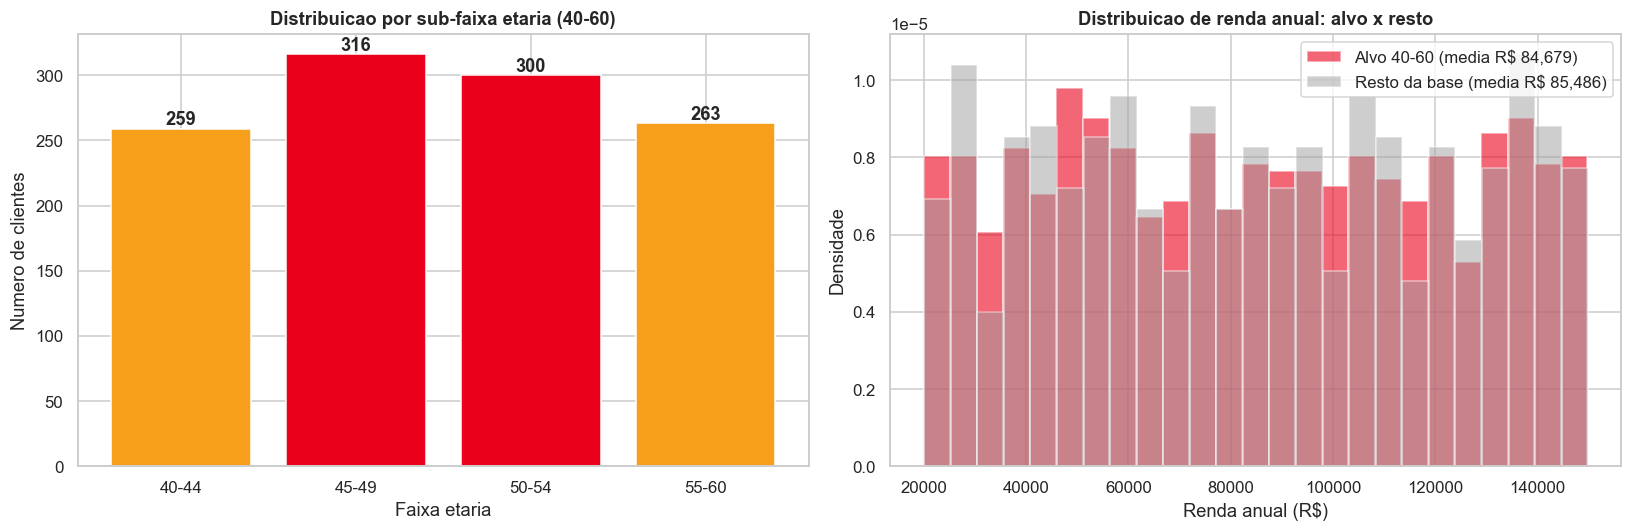

Sub-faixas: {'40-44': 259, '45-49': 316, '50-54': 300, '55-60': 263}
Renda mediana alvo: R$ 84,300


In [2]:
# --- Demografia interna do segmento: sub-faixas etarias e renda ---
alvo['Subfaixa'] = pd.cut(alvo['Idade'], bins=[40, 45, 50, 55, 60.01],
                          right=False, labels=['40-44', '45-49', '50-54', '55-60'])
dist_faixa = alvo['Subfaixa'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# (1) Sub-faixas etarias
bars = ax1.bar(dist_faixa.index.astype(str), dist_faixa.values,
               color=[MC_ORANGE, MC_RED, MC_RED, MC_ORANGE])
ax1.set_title('Distribuicao por sub-faixa etaria (40-60)')
ax1.set_xlabel('Faixa etaria'); ax1.set_ylabel('Numero de clientes')
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height(), f'{int(b.get_height())}',
             ha='center', va='bottom', fontweight='bold')

# (2) Distribuicao de renda: alvo x resto da base
ax2.hist(alvo['Renda_Anual'].dropna(), bins=25, color=MC_RED, alpha=0.6,
         label=f'Alvo 40-60 (media R$ {alvo["Renda_Anual"].mean():,.0f})', density=True)
ax2.hist(resto['Renda_Anual'].dropna(), bins=25, color=MC_GRAY, alpha=0.5,
         label=f'Resto da base (media R$ {resto["Renda_Anual"].mean():,.0f})', density=True)
ax2.set_title('Distribuicao de renda anual: alvo x resto')
ax2.set_xlabel('Renda anual (R$)'); ax2.set_ylabel('Densidade')
ax2.legend()

plt.tight_layout()
plt.savefig(GRAF / 'eda_demografia.png', bbox_inches='tight')
plt.show()

print('Sub-faixas:', dist_faixa.to_dict())
print(f'Renda mediana alvo: R$ {alvo["Renda_Anual"].median():,.0f}')

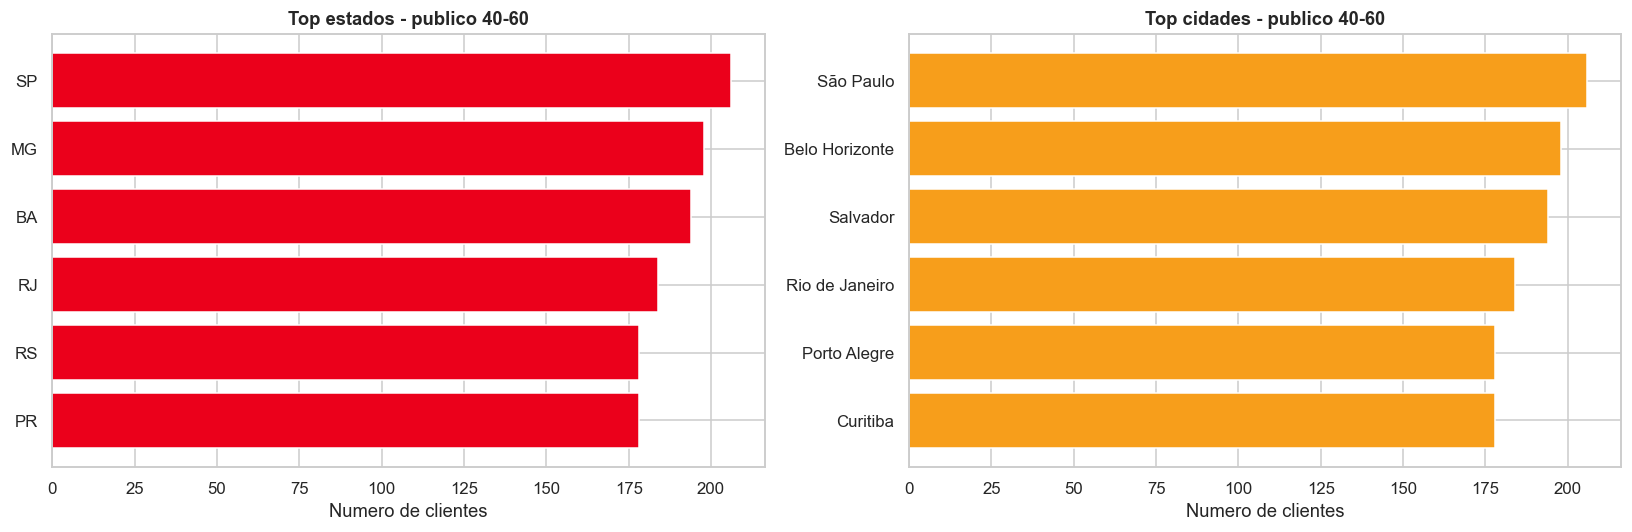

Top estados: {'SP': 206, 'MG': 198, 'BA': 194, 'RJ': 184, 'RS': 178, 'PR': 178}


In [3]:
# --- Distribuicao geografica do segmento ---
top_estados = alvo['Estado'].value_counts().head(8)
top_cidades = alvo['Cidade'].value_counts().head(8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.barh(top_estados.index[::-1], top_estados.values[::-1], color=MC_RED)
ax1.set_title('Top estados - publico 40-60')
ax1.set_xlabel('Numero de clientes')

ax2.barh(top_cidades.index[::-1], top_cidades.values[::-1], color=MC_ORANGE)
ax2.set_title('Top cidades - publico 40-60')
ax2.set_xlabel('Numero de clientes')

plt.tight_layout()
plt.savefig(GRAF / 'eda_geografia.png', bbox_inches='tight')
plt.show()

print('Top estados:', top_estados.to_dict())

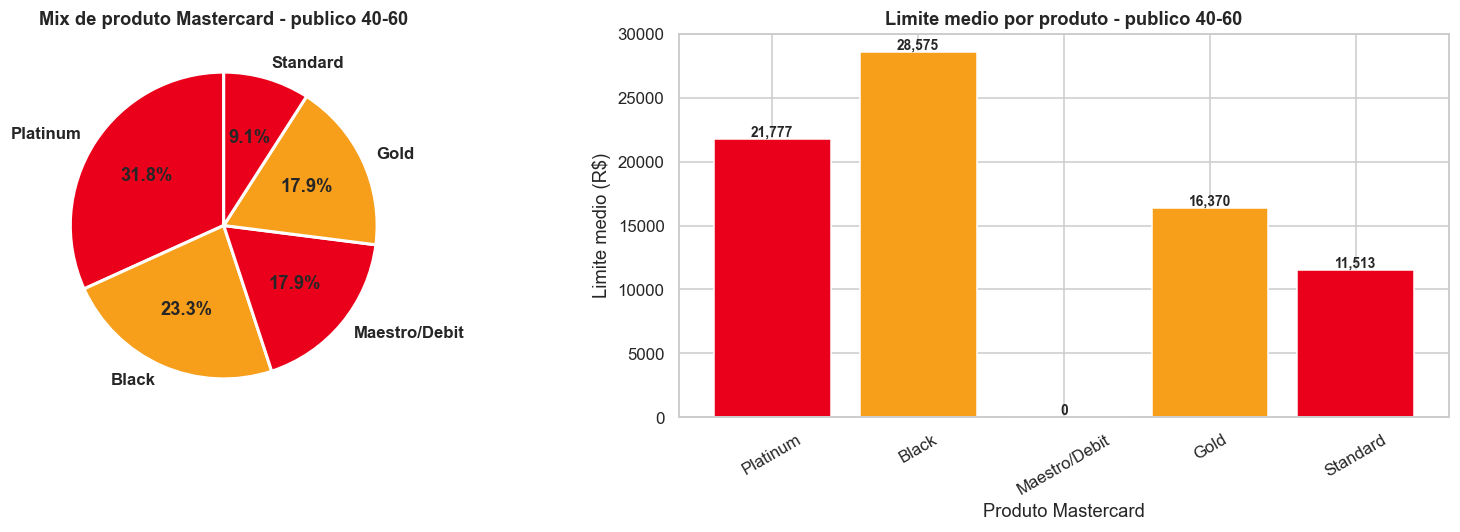

Mix produto (%): {'Platinum': 31.8, 'Black': 23.3, 'Maestro/Debit': 17.9, 'Gold': 17.9, 'Standard': 9.1}
Limite medio geral do segmento: R$ 17,554


In [4]:
# --- Mix de produto Mastercard e limite (join transacoes -> cartoes) ---
tx_cart = transacoes.merge(cartoes[['ID_Cartao', 'Produto_Mastercard', 'Limite_Cartao']],
                           on='ID_Cartao', how='left')
alvo_cart = (tx_cart[tx_cart['Cliente_ID'].isin(alvo_ids)]
             .drop_duplicates('Cliente_ID'))

mix_prod = alvo_cart['Produto_Mastercard'].value_counts()
limite_prod = (alvo_cart.groupby('Produto_Mastercard')['Limite_Cartao']
               .mean().reindex(mix_prod.index))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

cores = [MC_RED if i % 2 == 0 else MC_ORANGE for i in range(len(mix_prod))]
ax1.pie(mix_prod.values, labels=mix_prod.index, colors=cores, autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontweight': 'bold'})
ax1.set_title('Mix de produto Mastercard - publico 40-60')

bars = ax2.bar(limite_prod.index, limite_prod.values, color=cores)
ax2.set_title('Limite medio por produto - publico 40-60')
ax2.set_xlabel('Produto Mastercard'); ax2.set_ylabel('Limite medio (R$)')
ax2.tick_params(axis='x', rotation=30)
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():,.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(GRAF / 'eda_produtos.png', bbox_inches='tight')
plt.show()

print('Mix produto (%):', (mix_prod / mix_prod.sum() * 100).round(1).to_dict())
print(f'Limite medio geral do segmento: R$ {alvo_cart["Limite_Cartao"].mean():,.0f}')

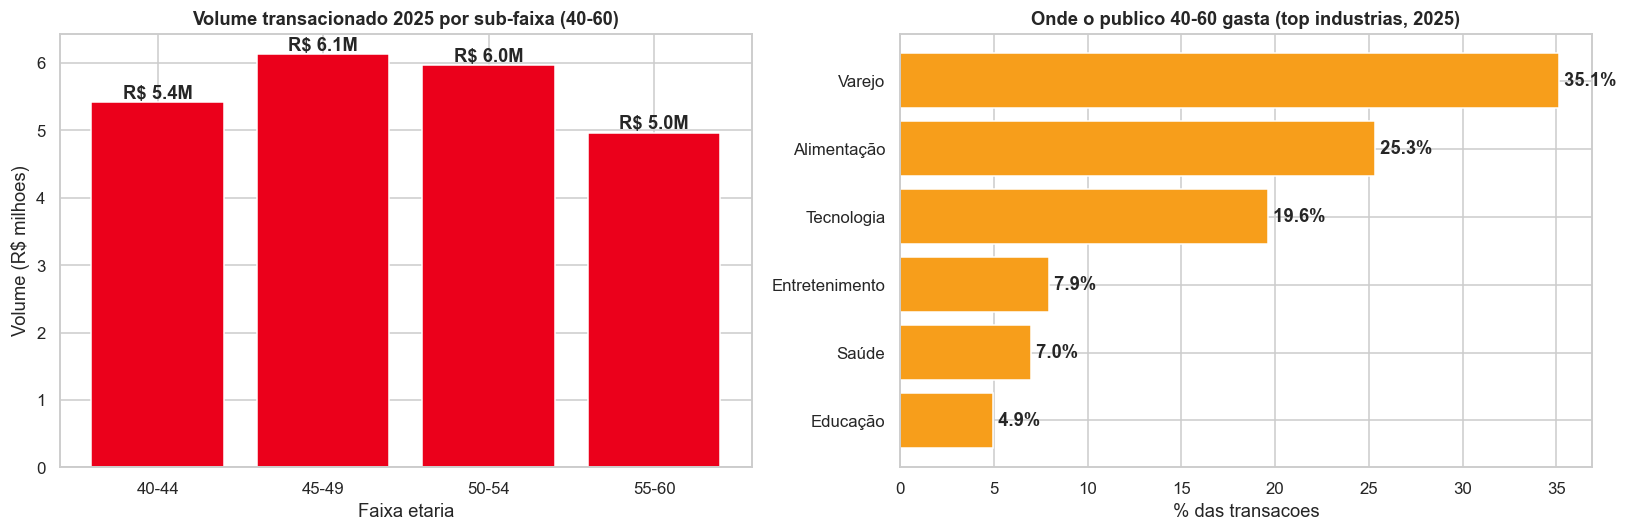

Ticket medio do segmento (2025): R$ 613.62
Transacoes medias por cliente ativo: 42.7
Top industrias (%): {'Varejo': 35.1, 'Alimentação': 25.3, 'Tecnologia': 19.6, 'Entretenimento': 7.9, 'Saúde': 7.0, 'Educação': 4.9}


In [5]:
# --- Comportamento transacional do segmento em 2025 ---
tx25_alvo = tx_2025[tx_2025['Cliente_ID'].isin(alvo_ids)].copy()

# volume por sub-faixa
sub_map = clientes.set_index('Cliente_ID')['Idade']
tx25_alvo['Subfaixa'] = pd.cut(tx25_alvo['Cliente_ID'].map(sub_map),
                               bins=[40, 45, 50, 55, 60.01], right=False,
                               labels=['40-44', '45-49', '50-54', '55-60'])
vol_faixa = tx25_alvo.groupby('Subfaixa', observed=True)['Valor_Compra'].sum() / 1e6
mix_industria = tx25_alvo['Industria'].value_counts(normalize=True).head(6) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

bars = ax1.bar(vol_faixa.index.astype(str), vol_faixa.values, color=MC_RED)
ax1.set_title('Volume transacionado 2025 por sub-faixa (40-60)')
ax1.set_xlabel('Faixa etaria'); ax1.set_ylabel('Volume (R$ milhoes)')
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height(), f'R$ {b.get_height():.1f}M',
             ha='center', va='bottom', fontweight='bold')

ax2.barh(mix_industria.index[::-1], mix_industria.values[::-1], color=MC_ORANGE)
ax2.set_title('Onde o publico 40-60 gasta (top industrias, 2025)')
ax2.set_xlabel('% das transacoes')
for i, v in enumerate(mix_industria.values[::-1]):
    ax2.text(v, i, f' {v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(GRAF / 'eda_consumo.png', bbox_inches='tight')
plt.show()

print(f'Ticket medio do segmento (2025): R$ {tx25_alvo["Valor_Compra"].mean():,.2f}')
print(f'Transacoes medias por cliente ativo: {tx25_alvo.groupby("Cliente_ID").size().mean():.1f}')
print('Top industrias (%):', mix_industria.round(1).to_dict())

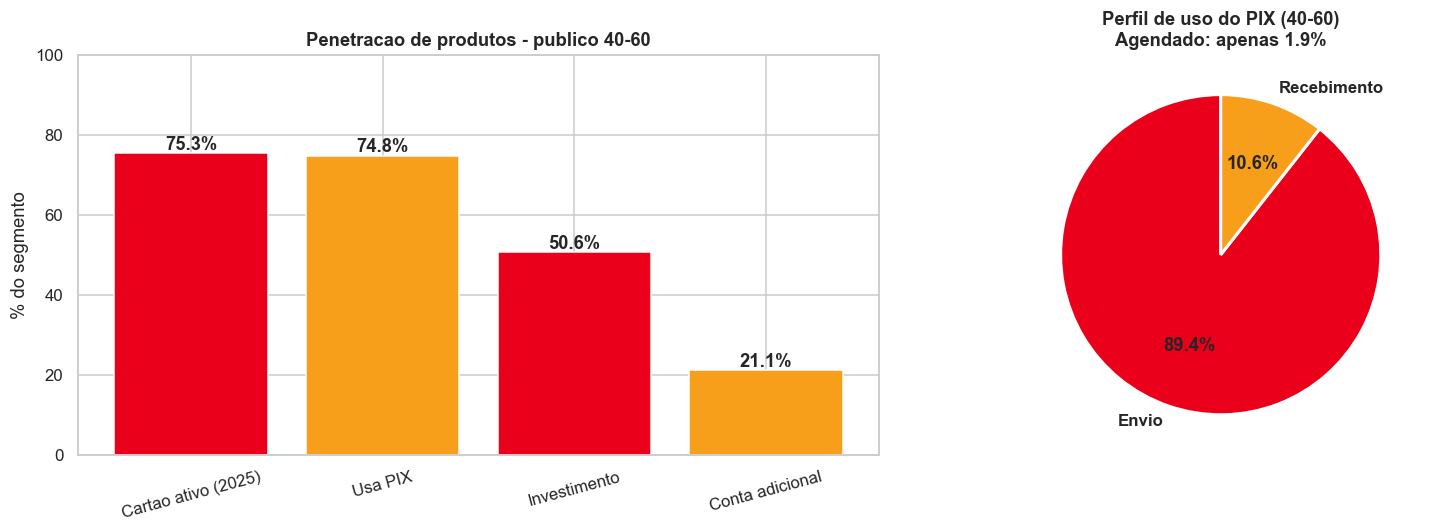

Penetracao (%): {'Cartao ativo (2025)': 75.3, 'Usa PIX': 74.8, 'Investimento': 50.6, 'Conta adicional': 21.1}
PIX agendado: 1.9% | Envio domina com 89.3%


In [6]:
# --- Penetracao de produtos no segmento 40-60 ---
pix_ids_alvo = set(pix[pix['Cliente_ID'].isin(alvo_ids)]['Cliente_ID'])
card_ids_25  = set(tx_2025[tx_2025['Cliente_ID'].isin(alvo_ids)]['Cliente_ID'])

penetr = pd.Series({
    'Cartao ativo (2025)': len(card_ids_25) / n_alvo * 100,
    'Usa PIX':             alvo['Cliente_ID'].isin(pix_ids_alvo).mean() * 100,
    'Investimento':        alvo['Cliente_ID'].isin(inv_ids).mean() * 100,
    'Conta adicional':     (alvo['Possui_Conta_Adicional'] == 'Sim').mean() * 100,
})

pix_alvo = pix[pix['Cliente_ID'].isin(alvo_ids)]
pix_perfil = pd.Series({
    'Envio':       (pix_alvo['Tipo_transacao'] == 'Envio').mean() * 100,
    'Recebimento': (pix_alvo['Tipo_transacao'] == 'Recebimento').mean() * 100,
})
pct_agendado = (pix_alvo['Agendado'] == 'Sim').mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

cores = [MC_RED if i % 2 == 0 else MC_ORANGE for i in range(len(penetr))]
bars = ax1.bar(penetr.index, penetr.values, color=cores)
ax1.set_title('Penetracao de produtos - publico 40-60')
ax1.set_ylabel('% do segmento'); ax1.set_ylim(0, 100)
ax1.tick_params(axis='x', rotation=15)
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.1f}%',
             ha='center', va='bottom', fontweight='bold')

ax2.pie(pix_perfil.values, labels=pix_perfil.index, colors=[MC_RED, MC_ORANGE],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontweight': 'bold'})
ax2.set_title(f'Perfil de uso do PIX (40-60)\nAgendado: apenas {pct_agendado:.1f}%')

plt.tight_layout()
plt.savefig(GRAF / 'eda_penetracao.png', bbox_inches='tight')
plt.show()

print('Penetracao (%):', penetr.round(1).to_dict())
print(f'PIX agendado: {pct_agendado:.1f}% | Envio domina com {pix_perfil["Envio"]:.1f}%')

## 2. Sintese - quem e o publico-alvo de 40 a 60 anos

**Tamanho e valor**
- **58,1% da base** (1.138 clientes) - e o segmento principal, nao um nicho
- Renda anual media de **~R$ 85 mil**, equivalente ao resto da base (nao e diferenciacao de renda, e de ciclo de vida)
- Distribuicao homogenea entre sub-faixas (40-44, 45-49, 50-54, 55-60) e bem pulverizada geograficamente (SP, MG, BA, RJ, RS, PR)

**Comportamento**
- **75,3% ativos no cartao em 2025**, ticket medio de **~R$ 614** (em linha com a base)
- Mix de produto **premium**: Platinum (31,8%) + Black (23,3%) somam mais da metade; limite medio de **~R$ 17,5 mil**
- Consumo concentrado em **Varejo (35%), Alimentacao (25%) e Tecnologia (20%)**
- **50,6% investem** e **74,8% usam PIX** - mas PIX agendado e quase nulo (1,9%) e conta adicional fica em 21,1%

**Leitura estrategica**
Esse e um cliente **maduro, de bom poder aquisitivo e ja portador de produto premium** - portanto rentavel e defensavel. O ponto fraco nao e adesao (cartao, PIX e investimento tem boa penetracao), e sim **recorrencia e ancoragem**: pouca conta adicional, PIX sem agendamento e produtos que nao se reforcam. A oportunidade aqui e **aprofundar** (principalidade, recorrencia, bundles premium), enquanto a aquisicao de jovens (vista nas hipoteses) corre como frente separada de crescimento.

## 3. Mercado e produtos do Pix no crédito

Gera os gráficos `prod_*` usados na proposta e no relatório. Recorte de mercado: 2025Q4.
Pix limpo = `Valor>0`, `Data` não nula, dedup; "aprovado" filtra `Aprovado==1`.

25Q4  enviado=34.1M  Pix->PJ=19.9M  Pix->PJ aprovado=17.9M


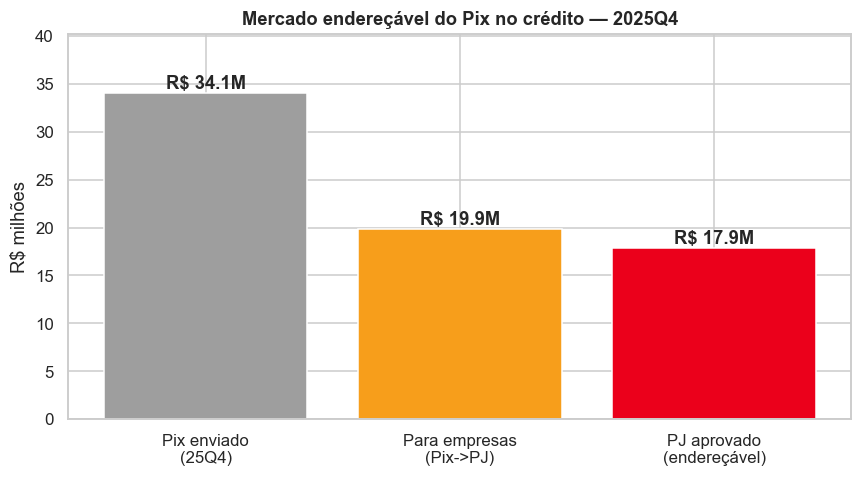

In [7]:
# ===== Preparacao do Pix e mercado enderecavel (2025Q4) =====
NAVY = '#1A1A2E'
IC_CRED = 0.018

pix['Data'] = pd.to_datetime(pix['Data'], errors='coerce')
pix['PF_PJ'] = pix['PF_PJ'].astype(str).str.strip().str.upper()
pix_d = pix.drop_duplicates()
pix_env = pix_d[(pix_d['Valor'] > 0) & pix_d['Data'].notna() & (pix_d['Tipo_transacao'] == 'Envio')].copy()
pix_env['YQ'] = pix_env['Data'].dt.to_period('Q').astype(str)
pix_aprov = pix_env[pix_env['Aprovado'] == 1].copy()

q4 = pix_env[pix_env['YQ'] == '2025Q4']
tot_env_q4  = q4['Valor'].sum()
pj_q4       = q4[q4['PF_PJ'] == 'PJ']['Valor'].sum()
pj_aprov_q4 = pix_aprov[(pix_aprov['YQ'] == '2025Q4') & (pix_aprov['PF_PJ'] == 'PJ')]['Valor'].sum()
print(f'25Q4  enviado={tot_env_q4/1e6:.1f}M  Pix->PJ={pj_q4/1e6:.1f}M  Pix->PJ aprovado={pj_aprov_q4/1e6:.1f}M')

fig, ax = plt.subplots(figsize=(8, 4.5))
vals = [tot_env_q4/1e6, pj_q4/1e6, pj_aprov_q4/1e6]
labs = ['Pix enviado\n(25Q4)', 'Para empresas\n(Pix->PJ)', 'PJ aprovado\n(endereçável)']
bars = ax.bar(labs, vals, color=[MC_GRAY, MC_ORANGE, MC_RED])
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f'R$ {v:.1f}M', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('R$ milhões'); ax.set_ylim(0, max(vals)*1.18)
ax.set_title('Mercado endereçável do Pix no crédito — 2025Q4')
plt.tight_layout(); plt.savefig(GRAF/'prod_mercado.png', bbox_inches='tight'); plt.show()


Volume Pix->PJ com ticket >= R$500: 69%


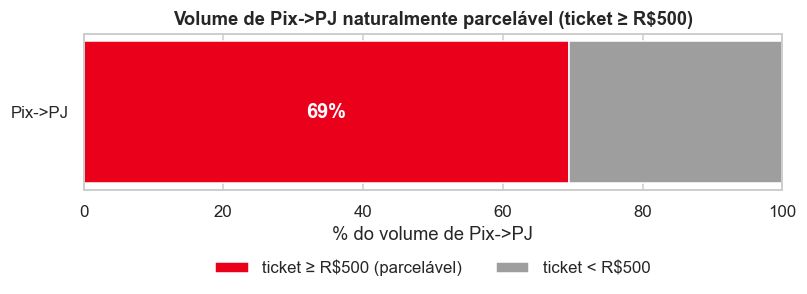

In [8]:
# ===== Ticket parcelavel: % do volume de Pix->PJ com ticket >= R$500 (todo o periodo) =====
pj_all = pix_aprov[pix_aprov['PF_PJ'] == 'PJ']
v = pj_all['Valor']
share_ge = v[v >= 500].sum() / v.sum() * 100
share_lt = 100 - share_ge
print(f'Volume Pix->PJ com ticket >= R$500: {share_ge:.0f}%')

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.barh(['Pix->PJ'], [share_ge], color=MC_RED, label='ticket ≥ R$500 (parcelável)')
ax.barh(['Pix->PJ'], [share_lt], left=[share_ge], color=MC_GRAY, label='ticket < R$500')
ax.text(share_ge/2, 0, f'{share_ge:.0f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=13)
ax.set_xlim(0, 100); ax.set_xlabel('% do volume de Pix->PJ')
ax.set_title('Volume de Pix->PJ naturalmente parcelável (ticket ≥ R$500)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)
plt.tight_layout(); plt.savefig(GRAF/'prod_ticket.png', bbox_inches='tight'); plt.show()


Pix->PJ: 1430 clientes | com credito ATIVO: 998 (70%)
Pix->PJ por cliente (R$ mil):
Faixa
18-29    68.5
30-39    36.9
40-49    37.7
50-59    38.7
60-69    35.5
70+      44.8


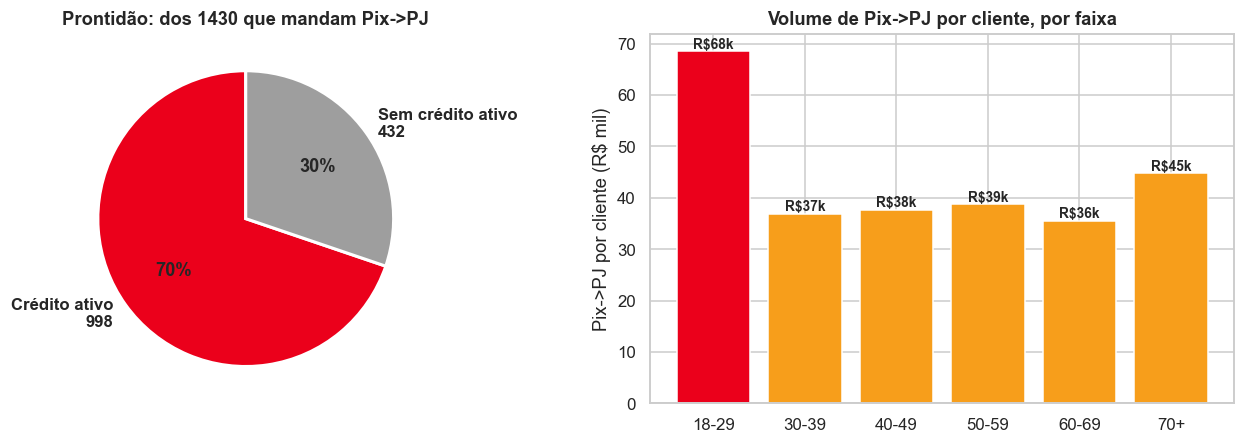

In [9]:
# ===== Prontidao: quem manda Pix->PJ e ja tem credito ativo; Pix->PJ por cliente/faixa =====
# cartoes nao tem Cliente_ID -> mapear via transacoes
card2cli = transacoes.dropna(subset=['ID_Cartao','Cliente_ID']).groupby('ID_Cartao')['Cliente_ID'].agg(lambda s: s.mode().iat[0])
cart = cartoes.copy()
cart['Cliente_ID'] = cart['ID_Cartao'].map(card2cli)
cart['inativo'] = ~cart['ID_Cartao'].isin(set(transacoes['ID_Cartao']))

pj_clientes = set(pix_aprov[pix_aprov['PF_PJ'] == 'PJ']['Cliente_ID'].unique())
cred_ativo  = set(cart[(cart['Tipo_Cartao'] == 'Crédito') & (~cart['inativo'])].dropna(subset=['Cliente_ID'])['Cliente_ID'])
prontos = pj_clientes & cred_ativo
print(f'Pix->PJ: {len(pj_clientes)} clientes | com credito ATIVO: {len(prontos)} ({len(prontos)/len(pj_clientes)*100:.0f}%)')

# Pix->PJ por cliente, por faixa (ref 2026-06-13 p/ casar com o diagnostico)
ref = pd.Timestamp('2026-06-13')
cl = clientes.copy()
cl['IdadeR'] = ((ref - cl['Data_Nascimento']).dt.days/365.25)
cl['Faixa'] = pd.cut(cl['IdadeR'], bins=[18,30,40,50,60,70,100],
                     labels=['18-29','30-39','40-49','50-59','60-69','70+'], right=False)
pjf = pix_aprov[pix_aprov['PF_PJ'] == 'PJ'].merge(cl[['Cliente_ID','Faixa']], on='Cliente_ID', how='left')
por_cli = (pjf.groupby('Faixa')['Valor'].sum() / pjf.groupby('Faixa')['Cliente_ID'].nunique()).reindex(
    ['18-29','30-39','40-49','50-59','60-69','70+'])
print('Pix->PJ por cliente (R$ mil):'); print((por_cli/1e3).round(1).to_string())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
nao = len(pj_clientes)-len(prontos)
a1.pie([len(prontos), nao],
       labels=[f'Crédito ativo\n{len(prontos)}', f'Sem crédito ativo\n{nao}'],
       colors=[MC_RED, MC_GRAY], autopct='%1.0f%%', startangle=90,
       textprops={'fontweight':'bold'}, wedgeprops={'edgecolor':'white','linewidth':2})
a1.set_title(f'Prontidão: dos {len(pj_clientes)} que mandam Pix->PJ')
cores = [MC_RED if f == '18-29' else MC_ORANGE for f in por_cli.index]
b = a2.bar(por_cli.index.astype(str), por_cli.values/1e3, color=cores)
for bar, val in zip(b, por_cli.values/1e3):
    a2.text(bar.get_x()+bar.get_width()/2, val, f'R${val:.0f}k', ha='center', va='bottom', fontweight='bold', fontsize=9)
a2.set_ylabel('Pix->PJ por cliente (R$ mil)'); a2.set_title('Volume de Pix->PJ por cliente, por faixa')
plt.tight_layout(); plt.savefig(GRAF/'prod_crosssell.png', bbox_inches='tight'); plt.show()


Elegíveis (Reservinha >= R$1k e com cartão): 634
Limite médio atual: R$ 43,604  ->  com Reservinha de lastro: R$ 79,525


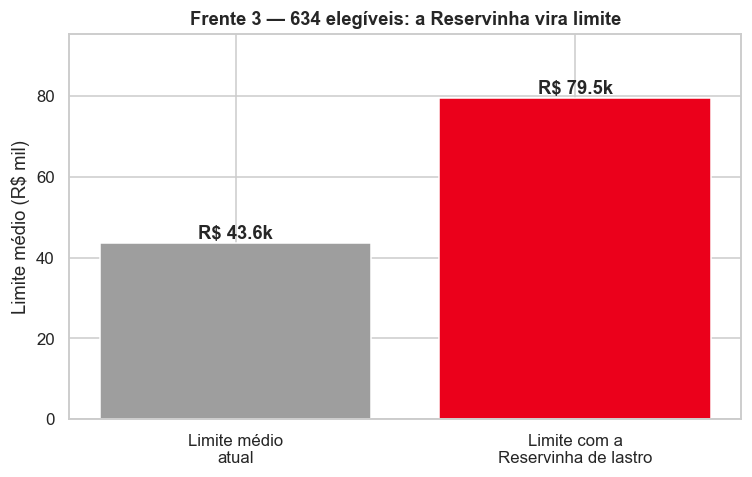

In [10]:
# ===== Frente 3: a Reservinha como ancora de limite =====
resv = investimentos[investimentos['Produto_Investimento'] == 'Reservinha'].copy()
resv['Data_dt'] = pd.to_datetime(resv['Data'].astype(str), format='%Y%m', errors='coerce')
saldo = resv.sort_values('Data_dt').groupby('Cliente_ID')['Saldo_Atual'].last()
elig  = saldo[saldo >= 1000]
lim_cli  = cart.dropna(subset=['Cliente_ID']).groupby('Cliente_ID')['Limite_Cartao'].sum()
elig_lim = lim_cli.reindex(elig.index).dropna()
lim_atual  = elig_lim.mean()
lim_lastro = (elig_lim + elig.reindex(elig_lim.index)).mean()
print(f'Elegíveis (Reservinha >= R$1k e com cartão): {len(elig_lim)}')
print(f'Limite médio atual: R$ {lim_atual:,.0f}  ->  com Reservinha de lastro: R$ {lim_lastro:,.0f}')

fig, ax = plt.subplots(figsize=(7, 4.5))
y = [lim_atual/1e3, lim_lastro/1e3]
bars = ax.bar(['Limite médio\natual', 'Limite com a\nReservinha de lastro'], y, color=[MC_GRAY, MC_RED])
for b, val in zip(bars, y):
    ax.text(b.get_x()+b.get_width()/2, val, f'R$ {val:.1f}k', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Limite médio (R$ mil)'); ax.set_ylim(0, max(y)*1.2)
ax.set_title(f'Frente 3 — {len(elig_lim)} elegíveis: a Reservinha vira limite')
plt.tight_layout(); plt.savefig(GRAF/'prod_investlimite.png', bbox_inches='tight'); plt.show()


conversão 20%: R$ 129k/tri
conversão 30%: R$ 193k/tri
conversão 50%: R$ 322k/tri


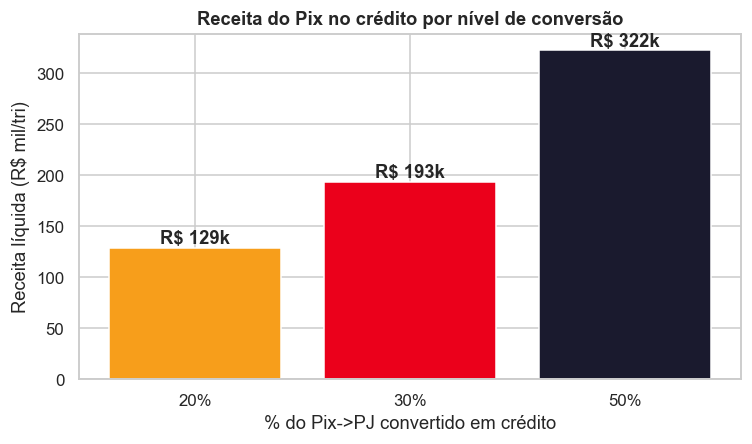

In [11]:
# ===== Receita do Pix no credito por nivel de conversao (trimestral) =====
# receita liquida = intercambio (1,8%) + margem de credito (1,8%, premissa)
MARGEM_CRED = 0.018
convs = [0.20, 0.30, 0.50]
receita = [pj_aprov_q4 * c * (IC_CRED + MARGEM_CRED) / 1e3 for c in convs]
for c, r in zip(convs, receita):
    print(f'conversão {c*100:.0f}%: R$ {r:.0f}k/tri')

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar([f'{int(c*100)}%' for c in convs], receita, color=[MC_ORANGE, MC_RED, NAVY])
for b, r in zip(bars, receita):
    ax.text(b.get_x()+b.get_width()/2, r, f'R$ {r:.0f}k', ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('% do Pix->PJ convertido em crédito'); ax.set_ylabel('Receita líquida (R$ mil/tri)')
ax.set_title('Receita do Pix no crédito por nível de conversão')
plt.tight_layout(); plt.savefig(GRAF/'prod_receita.png', bbox_inches='tight'); plt.show()
